#Speech Dataset Analysis and Classification
###CS 4403 – Data Mining Term Project

**Group Members :**  
Chanchalpreet Kaur    
Fatima Asif    
Medha Madhub

**Project Goal :**  
The goal of this project is to analyze and compare multiple speech based text datasets to identify patterns and differences..  
We aim to clean, explore and analyze speech transcripts using data mining techniques.  
The project will involve text preprocessing, visualization of patterns and applying machine learning models to classify and analyze speech data.

**Datasets Used:**  
- TED Talks transcripts dataset (`transcripts.csv`)
- TED Talks metadata dataset (`ted_main.csv`)
- Mozilla Common Voice speech dataset (`cv-valid-train.csv`)
- Synthetic speech dataset (`synthetic_speech_dataset_2000.csv`)


**Tools Used :**  
Python, Pandas, Scikit-learn and data visualization libraries.

---

## Dataset Summary

The project uses three speech based text datasets collected from publicly available sources:

• **TED Talks transcripts dataset** – real spoken presentations from TED Talks.  
Source: Kaggle – https://www.kaggle.com/datasets/rounakbanik/ted-talks  

• **Mozilla Common Voice dataset** – crowd-sourced spoken sentences collected to improve speech recognition systems.  
Source: Mozilla Common Voice / Kaggle – https://www.kaggle.com/datasets/mozillaorg/common-voice  

• **Synthetic speech dataset** – artificially generated text sentences created using ChatGPT to simulate realistic speech data.  
Source: Generated for this project using AI based text generation.

After cleaning and preprocessing, the datasets were combined into a single dataset containing speech text and a **source label** indicating whether the text originated from TED, Mozilla or a synthetic dataset.

---

## Data Mining Strategy

The project focuses on text-based speech analysis using machine learning.

The following approach will be used:

1. Text preprocessing and cleaning  
2. Feature extraction using TF-IDF  
3. Training classification models to distinguish between different speech datasets  
4. Evaluating models using classification metrics such as accuracy, precision, recall and F1-score

---

##1. Loading the Datasets

In this section, we load all datasets required for the project.  
These include real-world speech transcript datasets and a synthetic dataset generated for comparison purposes.

In [123]:
import pandas as pd

#loading the TED transcripts dataset(contains speech text)
ted_transcripts = pd.read_csv("transcripts.csv", engine='python', quotechar='"')

#loading the Mozilla Common Voice dataset(spoken sentence transcripts)
mozilla = pd.read_csv("cv-valid-train.csv")

#loading the synthetic speech dataset created for this project
synthetic = pd.read_csv("synthetic_speech_dataset_2000.csv")

#loading the TED metadata dataset(information about talks)
ted_meta = pd.read_csv("ted_main.csv")

#displaying the size of each dataset to confirm successful loading
print("TED transcripts :", ted_transcripts.shape)
print("Mozilla dataset :", mozilla.shape)
print("Synthetic dataset :", synthetic.shape)
print("TED metadata :", ted_meta.shape)

TED transcripts : (2467, 2)
Mozilla dataset : (195776, 8)
Synthetic dataset : (2000, 1)
TED metadata : (2550, 17)


##2. Exploring the Datasets

Before performing data cleaning, we first examine the structure of each dataset.  
This helps identify relevant columns and understand the type of data contained in each dataset.

In [124]:
#displaying the first few rows of each dataset
print("TED Transcripts Dataset")
display(ted_transcripts.head())

print("Mozilla Dataset")
display(mozilla.head())

print("Synthetic Dataset")
display(synthetic.head())

print("TED Metadata Dataset")
display(ted_meta.head())

TED Transcripts Dataset


,transcript,url
0,Good morning. How are you?(Laughter)It's been ...,https://www.ted.com/talks/ken_robinson_says_sc...
1,"Thank you so much, Chris. And it's truly a gre...",https://www.ted.com/talks/al_gore_on_averting_...
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",https://www.ted.com/talks/david_pogue_says_sim...
3,If you're here today — and I'm very happy that...,https://www.ted.com/talks/majora_carter_s_tale...
4,"About 10 years ago, I took on the task to teac...",https://www.ted.com/talks/hans_rosling_shows_t...


Mozilla Dataset


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the o...,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dr...,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those ome...,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me...,3,2,NaN,NaN,NaN,NaN


Synthetic Dataset


,text
0,My brother decided that the campus looked beau...
1,My roommate remembered that the coffee shop wa...
2,My roommate mentioned that the evening felt ca...
3,My brother noticed that the lecture was surpri...
4,My brother thought that the coffee shop was fu...


TED Metadata Dataset


,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


##3. Inspecting Dataset Columns

In this step, we examine the column names of each dataset to determine which columns contain the speech text that will be used for analysis and modeling.

In [125]:
#showing column names for each dataset

print("TED transcripts columns :")
print(ted_transcripts.columns)

print("\nMozilla dataset columns :")
print(mozilla.columns)

print("\nSynthetic dataset columns :")
print(synthetic.columns)

print("\nTED metadata columns :")
print(ted_meta.columns)

TED transcripts columns :
Index(['transcript', 'url'], dtype='object')

Mozilla dataset columns :
Index(['filename', 'text', 'up_votes', 'down_votes', 'age', 'gender', 'accent',
       'duration'],
      dtype='object')

Synthetic dataset columns :
Index(['text'], dtype='object')

TED metadata columns :
Index(['comments', 'description', 'duration', 'event', 'film_date',
       'languages', 'main_speaker', 'name', 'num_speaker', 'published_date',
       'ratings', 'related_talks', 'speaker_occupation', 'tags', 'title',
       'url', 'views'],
      dtype='object')


##4. Extracting Relevant Text Columns

Each dataset contains multiple columns but for this project we only need the columns that contain the speech text.  
This step extracts the relevant text columns from each dataset so they can be cleaned and analyzed later.

In [126]:
#extracting the text columns from each dataset

ted_text = ted_transcripts[['transcript']]
mozilla_text = mozilla[['text']]
synthetic_text = synthetic[['text']]

#displaying the first few rows to confirm extraction
print("TED text sample :")
display(ted_text.head())

print("Mozilla text sample :")
display(mozilla_text.head())

print("Synthetic text sample :")
display(synthetic_text.head())

TED text sample :


,transcript
0,Good morning. How are you?(Laughter)It's been ...
1,"Thank you so much, Chris. And it's truly a gre..."
2,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,If you're here today — and I'm very happy that...
4,"About 10 years ago, I took on the task to teac..."


Mozilla text sample :


,text
0,learn to recognize omens and follow them the o...
1,everything in the universe evolved he said
2,you came so that you could learn about your dr...
3,so now i fear nothing because it was those ome...
4,if you start your emails with greetings let me...


Synthetic text sample :


,text
0,My brother decided that the campus looked beau...
1,My roommate remembered that the coffee shop wa...
2,My roommate mentioned that the evening felt ca...
3,My brother noticed that the lecture was surpri...
4,My brother thought that the coffee shop was fu...


##5. Combining the Datasets

After extracting the relevant text columns, the datasets are combined into a single dataset.  
A new column called **source** is added to indicate where each text sample originated from.

In [127]:
#renaming columns so all datasets have the same column name

ted_df = ted_text.rename(columns={'transcript' : 'text'})
mozilla_df = mozilla_text
synthetic_df = synthetic_text

#adding a source label to each dataset
ted_df['source'] = 'TED'
mozilla_df['source'] = 'Mozilla'
synthetic_df['source'] = 'Synthetic'

#combining all datasets into one
combined_data = pd.concat([ted_df, mozilla_df, synthetic_df], ignore_index=True)

#viewing the combined dataset
print("Combined dataset size:", combined_data.shape)
display(combined_data.head())

Combined dataset size: (200243, 2)


/tmp/ipykernel_1283/149411456.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mozilla_df['source'] = 'Mozilla'


,text,source
0,Good morning. How are you?(Laughter)It's been ...,TED
1,"Thank you so much, Chris. And it's truly a gre...",TED
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",TED
3,If you're here today — and I'm very happy that...,TED
4,"About 10 years ago, I took on the task to teac...",TED


##6. Data Cleaning

In this step, we clean the combined dataset by removing missing values and duplicate text entries.  
Cleaning the data ensures that the analysis and models are trained on reliable and meaningful text samples.

In [128]:
#removing rows with missing text
combined_data = combined_data.dropna(subset=['text'])

#removing duplicate text entries
combined_data = combined_data.drop_duplicates(subset=['text'])

#resetting index after cleaning
combined_data = combined_data.reset_index(drop = True)

#checking dataset size after cleaning
print("Dataset size after cleaning:", combined_data.shape)

#viewing sample rows
display(combined_data.head())

Dataset size after cleaning: (11103, 2)


,text,source
0,Good morning. How are you?(Laughter)It's been ...,TED
1,"Thank you so much, Chris. And it's truly a gre...",TED
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",TED
3,If you're here today — and I'm very happy that...,TED
4,"About 10 years ago, I took on the task to teac...",TED


##7. Text Preprocessing

To prepare the dataset for analysis and machine learning, the text must be normalized.  
This includes converting all text to lowercase and removing unnecessary whitespace.

In [129]:
#converting all text to lowercase
combined_data['text'] = combined_data['text'].str.lower()

#removing extra spaces
combined_data['text'] = combined_data['text'].str.strip()

#replacing multiple spaces with single space
combined_data['text'] = combined_data['text'].str.replace(r'\s+', ' ', regex=True)

#displaying sample after preprocessing
print("Sample after preprocessing:")
display(combined_data.head())

Sample after preprocessing:


,text,source
0,good morning. how are you?(laughter)it's been ...,TED
1,"thank you so much, chris. and it's truly a gre...",TED
2,"(music: ""the sound of silence,"" simon & garfun...",TED
3,if you're here today — and i'm very happy that...,TED
4,"about 10 years ago, i took on the task to teac...",TED


##8. Removing Punctuation and Special Characters

In this step, punctuation marks and special characters are removed from the text.  
This helps simplify the dataset and prepares it for feature extraction and machine learning models.

In [130]:
import re

#function to remove punctuation and special characters
def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

#applying the cleaning function
combined_data['text'] = combined_data['text'].apply(remove_punctuation)

#viewing sample after cleaning
print("Sample after removing punctuation :")
display(combined_data.head())

Sample after removing punctuation :


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


##9. Removing Very Short Text Entries

Some text entries may contain very few words and may not provide meaningful information for analysis.  
In this step, sentences with fewer than three words are removed from the dataset.

In [131]:
#counting number of words in each sentence
combined_data['word_count'] = combined_data['text'].apply(lambda x : len(x.split()))

#removing sentences with fewer than 3 words
combined_data = combined_data[combined_data['word_count'] >= 3]

#dropping the helper column
combined_data = combined_data.drop(columns=['word_count'])

#resetting index
combined_data = combined_data.reset_index(drop = True)

#checking dataset size after filtering
print("Dataset size after removing short sentences :", combined_data.shape)

#displaying sample
display(combined_data.head())

Dataset size after removing short sentences : (11083, 2)


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


##10. Saving the Cleaned Dataset

After completing the data cleaning and preprocessing steps, the cleaned dataset is saved.  
This dataset will be used later for classification models and visualization tasks in the project.

In [132]:
#save the cleaned dataset
combined_data.to_csv("cleaned_speech_dataset.csv", index = False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [133]:
print("Final cleaned dataset shape:", combined_data.shape)

print("\nSamples per dataset source:")
print(combined_data['source'].value_counts())

Final cleaned dataset shape: (11083, 2)

Samples per dataset source:
source
Mozilla      6979
TED          2459
Synthetic    1645
Name: count, dtype: int64


In [134]:
data = combined_data

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (11083, 2)


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


## Data Preparation Progress

The datasets were cleaned and standardized before analysis.  
The following preprocessing steps were performed:

• Extracted relevant text columns  
• Combined datasets into a single dataset  
• Removed missing and duplicate entries  
• Converted text to lowercase  
• Removed punctuation and special characters  
• Removed very short sentences  

The resulting cleaned dataset contains over 11000 speech text samples and will be used for feature extraction and classification.

##11. Feature Extraction Using TF-IDF

Before applying the models, text data is converted into numerical form.
Since the algorithms cannot directly process raw text, TF-IDF is used to transform each sentence into a numerical feature vector.
It highlight important words while reducing the impact of very common words.

In [135]:
from sklearn.feature_extraction.text import TfidfVectorizer

#creating the vectorizer to convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

#transforming the text column into a feature matrix
X = vectorizer.fit_transform(data["text"])

#setting the target labels (TED, Mozilla, Synthetic)
y = data["source"]

#displaying the shape of the feature matrix
print("Feature matrix shape:", X.shape)

Feature matrix shape: (11083, 5000)


# Top Words per Dataset Visuliazation

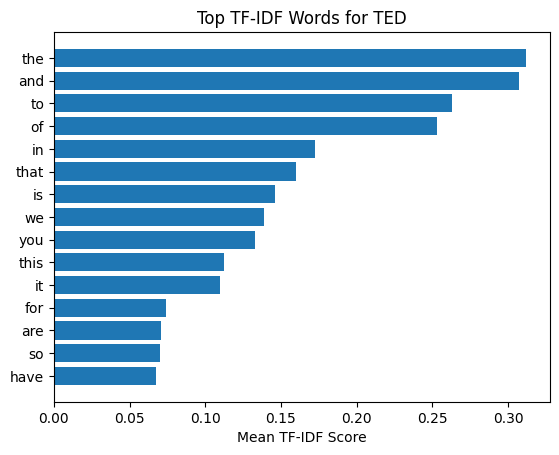

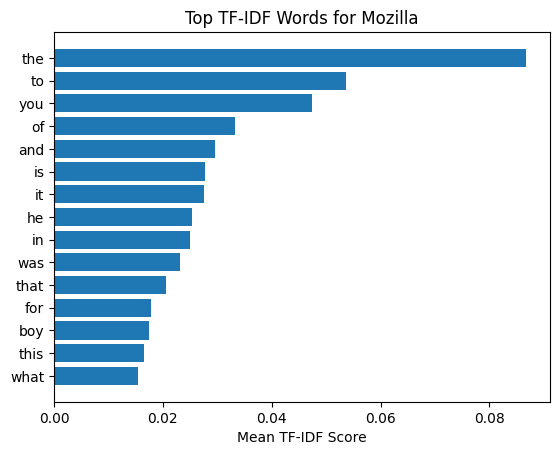

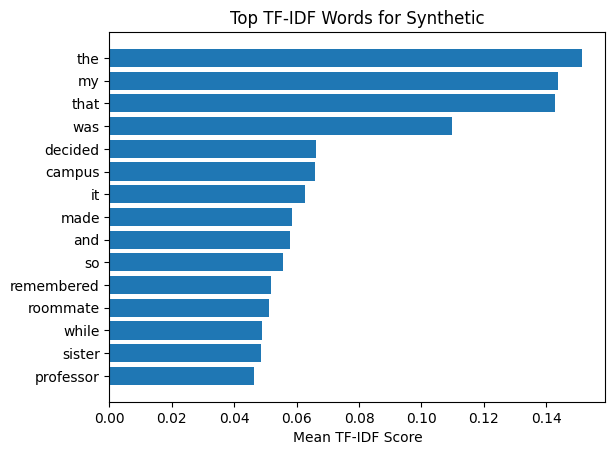

In [136]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array(vectorizer.get_feature_names_out())

def top_terms(source_name, top_n=15):
    idx = data['source'] == source_name
    X_source = X[idx.values]

    mean_tfidf = np.asarray(X_source.mean(axis=0)).ravel()  # 1D numpy array

    top_idx = mean_tfidf.argsort()[::-1][:top_n]
    terms = feature_names[top_idx]
    scores = mean_tfidf[top_idx]

    plt.figure()
    plt.barh(terms[::-1], scores[::-1])
    plt.title(f"Top TF-IDF Words for {source_name}")
    plt.xlabel("Mean TF-IDF Score")
    plt.show()

for s in data['source'].unique():
    top_terms(s)

**1. Top TF-IDF Words for TED**

The visualization shows the most important words in the TED transcripts according to their TF-IDF scores. Common words such as “the,” “and,” “to,” and “of” appear frequently, reflecting the natural structure of spoken English in speeches. Since TED talks are long conversational transcripts, many common connecting words appear prominently in the dataset.



**2. Top TF-IDF Words for Mozilla**

The Mozilla dataset also contains common English words such as “the,” “to,” “you,” and “of.” This is expected because the Mozilla Common Voice dataset consists of short spoken sentences collected from many speakers. The vocabulary reflects simple conversational phrases rather than long structured speech.

**3.Top TF-IDF Words for Synthetic Dataset**

The synthetic dataset shows a mix of common words and context-specific words such as “campus,” “roommate,” and “professor.” These words suggest that the synthetic sentences follow a narrative or story-like structure. Compared to the other datasets, the vocabulary is more specific to certain themes or situations.

##12. Splitting the Dataset into Training and Testing Sets

The dataset is divided into a training set and a testing set. The training set is used to train the models, while the testing set is used to evaluate how well the models perform on new data. This helps us measure the performance of the models.

In [137]:
from sklearn.model_selection import train_test_split

#splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (8866, 5000)
Testing size: (2217, 5000)


#Datastet Balance Visualization

The bar chart shows the number of text samples available from each dataset source. The datasets appear realively balanced, which helps prevent bias during model training. Having comparable numbers of samples from each source allows the classification algorithms to learn patterns more fairly across datasets.

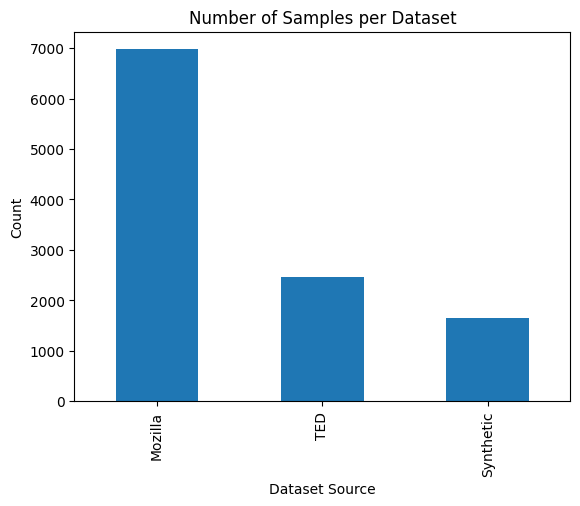

In [138]:
import matplotlib.pyplot as plt

counts = data['source'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Number of Samples per Dataset")
plt.xlabel("Dataset Source")
plt.ylabel("Count")
plt.show()

# Text Length Distribution Visualization

The visualization shows that TED transcripts are significantly longer than texts from the Mozilla and Synthetic datasets. TED speeches contain full speech transcripts, while the other datasets consist mostly of short sentences. This difference in text length indicates variation in dataset structure, which can affect feature extraction and model learning.

<Figure size 640x480 with 0 Axes>

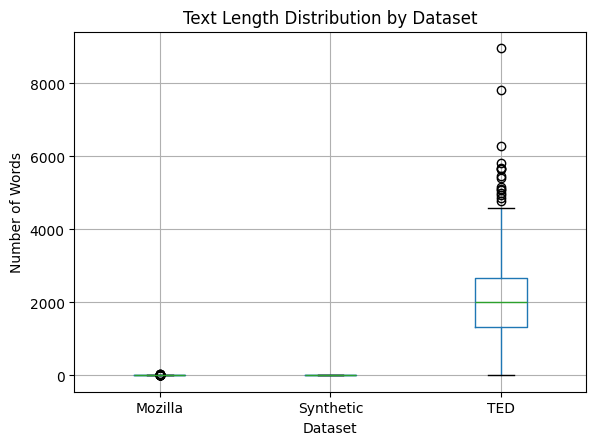

In [139]:
data['text_len_words'] = data['text'].apply(lambda x: len(str(x).split()))

plt.figure()
data.boxplot(column='text_len_words', by='source')
plt.title("Text Length Distribution by Dataset")
plt.suptitle("")
plt.xlabel("Dataset")
plt.ylabel("Number of Words")
plt.show()

##13. Training the Naive Bayes Classification Model

In this step, the Naive Bayes classifier is trained using the training data.
Naive Bayes is commonly used for text classification because it performs well with high-dimensional text features such as TF-IDF vectors.
The model will learn patterns that help identify whether a sentence comes from the TED, Mozilla, or Synthetic dataset.

In [140]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB

#creating the naive bayes classifier
nb_model = MultinomialNB()

#training the model using the training data
nb_model.fit(X_train, y_train)

#making predictions on the testing data
nb_predictions = nb_model.predict(X_test)

In [141]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9589535408209292


##14. Training the Logistic Regression Model

Logistic Regression is another classification algorithm used to predict the category of each text entry.
This model analyzes the relationship between the extracted features and the dataset labels.
Training multiple models allows us to compare their performance later in the experimentation stage.

In [142]:
from sklearn.linear_model import LogisticRegression

#creating the logistic regression classifier
lr_model = LogisticRegression(max_iter=1000)

#training the model using the training data
lr_model.fit(X_train, y_train)

#making predictions on the testing data
lr_predictions = lr_model.predict(X_test)

In [143]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9972936400541272


##15. Training the Support Vector Machine (SVM) Model

The Support Vector Machine(SVM) model is trained to classify the text data into the three dataset sources(TED, Mozilla and Synthetic).
SVM is effective for text classification tasks because it can handle large feature spaces and find optimal decision boundaries between classes.

In [144]:
from sklearn.svm import LinearSVC


#creating the SVM classifier
svm_model = LinearSVC()

#training the svm model using the training data
svm_model.fit(X_train, y_train)

#making predictions on the testing data
svm_predictions = svm_model.predict(X_test)

In [145]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9986468200270636


##16. Evaluating Model Performance

After training the models, their performance is evaluated using several classification metrics. These metrics include accuracy, precision, recall, and F1-score. These measures help determine how well each model correctly classifies the text data.

In [146]:
#evaluating the naive bayes model
print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print(classification_report(y_test, nb_predictions))

#evaluating the logistic regression model
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

#evaluating the svm model
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print(classification_report(y_test, svm_predictions))

Naive Bayes Results
Accuracy: 0.9589535408209292
              precision    recall  f1-score   support

     Mozilla       0.96      0.98      0.97      1404
   Synthetic       0.99      1.00      1.00       318
         TED       0.93      0.89      0.91       495

    accuracy                           0.96      2217
   macro avg       0.96      0.95      0.96      2217
weighted avg       0.96      0.96      0.96      2217

Logistic Regression Results
Accuracy: 0.9972936400541272
              precision    recall  f1-score   support

     Mozilla       1.00      1.00      1.00      1404
   Synthetic       1.00      1.00      1.00       318
         TED       1.00      0.99      0.99       495

    accuracy                           1.00      2217
   macro avg       1.00      1.00      1.00      2217
weighted avg       1.00      1.00      1.00      2217

SVM Results
Accuracy: 0.9986468200270636
              precision    recall  f1-score   support

     Mozilla       1.00      1.00   

##17. Confusion Matrix Analysis

The confusion matrix provides a detailed view of the classification results.
It shows how many instances were correctly or incorrectly predicted for each dataset source (TED, Mozilla, and Synthetic).
This helps identify which classes the models may confuse with one another.

In [147]:
#displaying the confusion matrix for the Naive Bayes model
print("Confusion Matrix (Naive Bayes)")
print(confusion_matrix(y_test, nb_predictions))

Confusion Matrix (Naive Bayes)
[[1369    2   33]
 [   0  318    0]
 [  56    0  439]]


In [148]:
#displaying the confusion matrix for the Logistic Regression model
print("Confusion Matrix (Logistic Regression)")
print(confusion_matrix(y_test, lr_predictions))

Confusion Matrix (Logistic Regression)
[[1404    0    0]
 [   0  318    0]
 [   6    0  489]]


In [149]:
#displaying the confusion matrix for the svm model
print("Confusion Matrix (SVM)")
print(confusion_matrix(y_test, svm_predictions))

Confusion Matrix (SVM)
[[1404    0    0]
 [   0  318    0]
 [   3    0  492]]


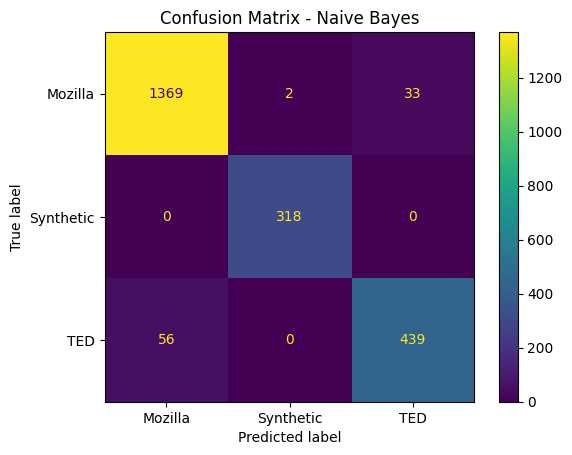

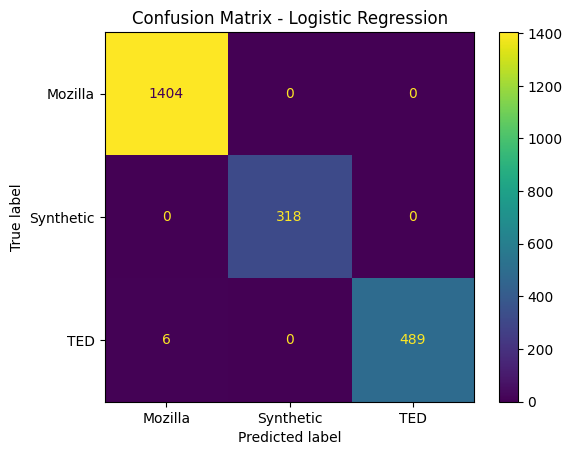

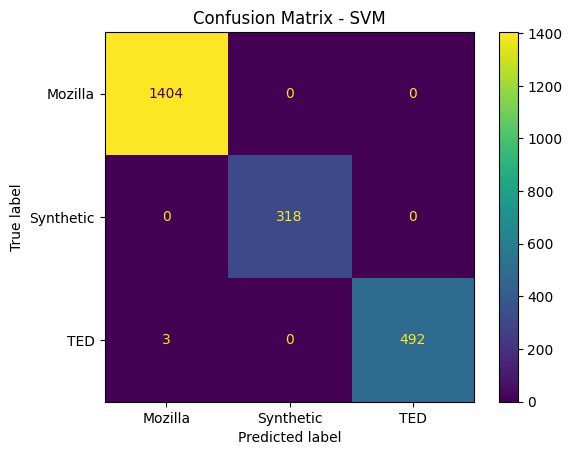

In [150]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#creating and displaying confusion matrix for all models
models = {"Naive Bayes": nb_predictions,"Logistic Regression": lr_predictions,"SVM": svm_predictions}

for model_name, predictions in models.items():
    #computing the confusion matrix
    cm = confusion_matrix(y_test, predictions)

    #creating visual display of the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

##18. Model Performance Comparison

In this step, the performance of the different classification models is compared using evaluation metrics such as accuracy, precision, recall, and F1-score. The results are organized into a table to make it easier to compare how well each model performs in classifying the text data. This helps identify which model works best for the dataset.

In [151]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

#creating a table to compare the performance of all models
results = {
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions, average = 'weighted'),
        precision_score(y_test, lr_predictions, average = 'weighted'),
        precision_score(y_test, svm_predictions, average = 'weighted')
    ],
    "Recall": [
        recall_score(y_test, nb_predictions, average = 'weighted'),
        recall_score(y_test, lr_predictions, average = 'weighted'),
        recall_score(y_test, svm_predictions, average = 'weighted')
    ],
    "F1-score": [
        f1_score(y_test, nb_predictions, average = 'weighted'),
        f1_score(y_test, lr_predictions, average = 'weighted'),
        f1_score(y_test, svm_predictions, average = 'weighted')
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.958954   0.958606  0.958954  0.958630
1  Logistic Regression  0.997294   0.997305  0.997294  0.997288
2                  SVM  0.998647   0.998650  0.998647  0.998645


##19. Model Performance Comparision Visualization

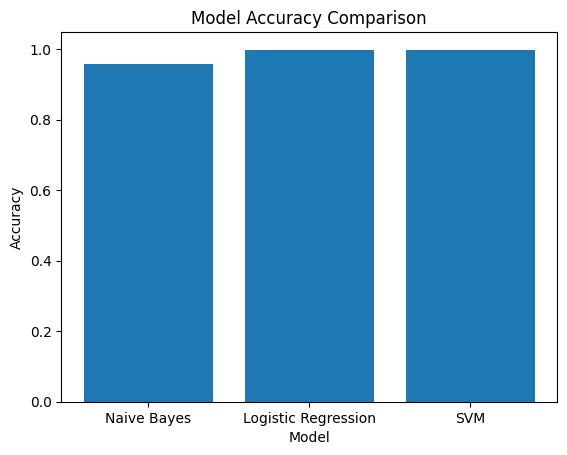

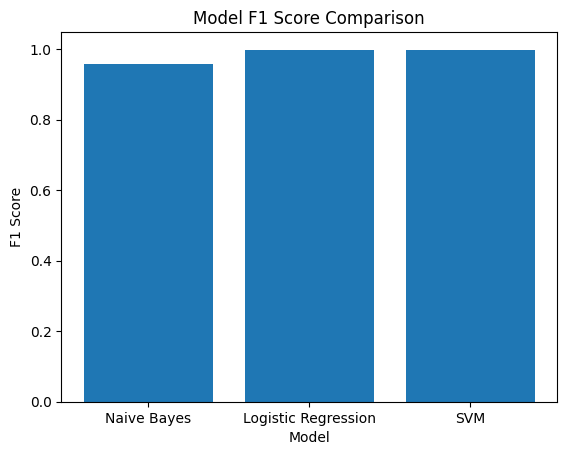

In [152]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()

**Model Accuracy Comparison**

This visualization compares the accuracy of the three machine learning models: Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). Logistic Regression and SVM achieve the highest accuracy, while Naive Bayes performs slightly lower. This indicates that Logistic Regression and SVM are better at learning patterns from the TF-IDF features and classifying the text sources correctly.

**Model F1 Score Comparison**

The F1-score comparison shows similar results to the accuracy graph. Logistic Regression and SVM achieve the highest F1-scores, indicating strong performance in balancing precision and recall. Naive Bayes performs slightly lower, suggesting it is somewhat less effective at distinguishing between the different text datasets.

##20. Random Forest Model

In [153]:
#============================================
#20. Random Forest Model
#============================================

#importing Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

#create Random Forest model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

#train the model
rf_model.fit(X_train, y_train)

#predict on test data
y_pred_rf = rf_model.predict(X_test)

#calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

#now printing accuracy
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9972936400541272


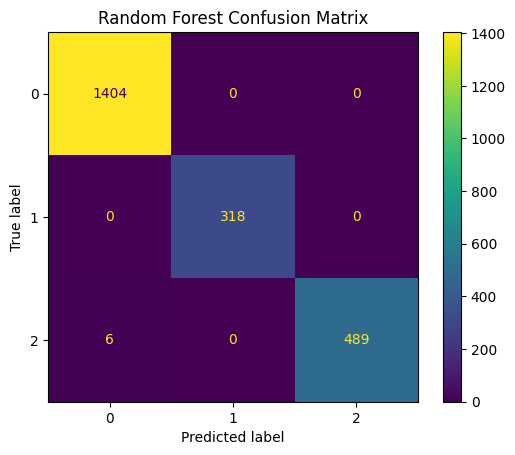

In [154]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#compute confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

#display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

*We analyzed Random Forest more deeply using confusion matrix and feature importance to understand model behavior.*

##21. Evaluating Random Forest Performance

In [155]:
#============================================
#21. Evaluating Random Forest Performance
#============================================

#printing classification report for Random Forest
print("Classification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:

              precision    recall  f1-score   support

     Mozilla       1.00      1.00      1.00      1404
   Synthetic       1.00      1.00      1.00       318
         TED       1.00      0.99      0.99       495

    accuracy                           1.00      2217
   macro avg       1.00      1.00      1.00      2217
weighted avg       1.00      1.00      1.00      2217



##22. Random Forest Confusion Matrix

In [156]:
#============================================
#22. Random Forest Confusion Matrix
#============================================

#printing confusion matrix for Random Forest
print("Confusion Matrix for Random Forest:\n")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix for Random Forest:

[[1404    0    0]
 [   0  318    0]
 [   6    0  489]]


##23. Model Performance Comparison

In [157]:
#============================================
#23. Updated Model Performance Comparison
#============================================

#store model names and their accuracies
model_names = ["Naive Bayes", "Logistic Regression", "SVM", "Random Forest"]
model_accuracies = [nb_accuracy, lr_accuracy, svm_accuracy, rf_accuracy]

#create a comparison table
comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": model_accuracies
})

#printing the comparison table
print(comparison_df)

                 Model  Accuracy
0          Naive Bayes  0.958954
1  Logistic Regression  0.997294
2                  SVM  0.998647
3        Random Forest  0.997294


###**Investigating Unexpectedly High Accuracy**

> **Important Observation**
>
> While the initial results showed very high accuracy across all models, feedback suggested that this performance may not reflect true learning but instead dataset-specific differences. Therefore, further investigation was conducted to examine the underlying reasons for this behavior.

##24. Random Forest Feature Importance Analysis

In [158]:
#============================================
#24. Random Forest Feature Importance Analysis
#============================================

#get feature importance scores from Random Forest
importances = rf_model.feature_importances_

#get feature names from TF-IDF
feature_names = vectorizer.get_feature_names_out()

#create a DataFrame of features and their importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

#sort by importance (highest first)
feature_importance_df = feature_importance_df.sort_values(by = "Importance", ascending = False)

#show top 20 important features
print("Top 20 Important Features:\n")
print(feature_importance_df.head(20))

Top 20 Important Features:

      Feature  Importance
2928       my    0.039314
4464     that    0.037869
4830       we    0.022726
4815      was    0.020779
580        by    0.016803
4876    which    0.015919
603       can    0.015270
4096       so    0.015136
4971    years    0.014586
4467      the    0.013876
4861     what    0.013728
134       all    0.012987
4879      who    0.012765
1843     from    0.011284
1115  decided    0.010855
4465    thats    0.010759
4869     when    0.010704
2883     more    0.010623
2172      how    0.010315
3082     only    0.010124


##Feature Importance Analysis

The feature importance results from the Random Forest model show that the most influential features are common words such as *"my", "that", "we", "was" and "which"*. These are not topic specific keywords but rather general function words that appear across different types of text.

This suggests that the model is not primarily relying on subject matter differences(e.g. technology vs speech content) but is instead capturing patterns in writing style and structure. This is a positive indication that the model is partially learning stylistic differences between real and synthetic text.

However, the extremely high accuracy(close to 99%) raises concerns that the model may still be exploiting subtle dataset specific biases rather than fully generalizing the distinction between real and synthetic data.

##Critical Reflection

Although the model achieves very high performance, this may not accurately reflect its ability to distinguish real from synthetic text in general scenarios. The results suggest that further feature engineering and dataset balancing are needed to ensure that the model focuses purely on stylistic characteristics rather than hidden dataset differences.

##25. Improved TF-IDF Feature Engineering

In [159]:
#============================================
#25. Improved TF-IDF Feature Engineering
#===========================================

from sklearn.feature_extraction.text import TfidfVectorizer

#create a more controlled TF-IDF(reduces bias)
vectorizer_improved = TfidfVectorizer(
    #limit vocabulary size
    max_features = 2000,
    #remove common words
    stop_words = 'english'
)

#fit and transform using correct column
X_improved = vectorizer_improved.fit_transform(data["text"])

#split into train and test again
from sklearn.model_selection import train_test_split

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y, test_size = 0.2, random_state = 42
)

##26. Random Forest Model(Improved Features)

In [160]:
#============================================
#26. Random Forest Model(Improved Features)
#============================================

#train model again on improved features
rf_model_imp = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model_imp.fit(X_train_imp, y_train_imp)

#predict
y_pred_rf_imp = rf_model_imp.predict(X_test_imp)

#accuracy
rf_imp_accuracy = accuracy_score(y_test_imp, y_pred_rf_imp)

print("Improved Random Forest Accuracy:", rf_imp_accuracy)

Improved Random Forest Accuracy: 0.995489400090212


##Improved Feature Engineering Analysis

After applying a more controlled TF IDF representation with a smaller vocabulary and English stopword removal, the Random Forest model achieved an accuracy of approximately 99.55%. This is only slightly lower than the original Random Forest accuracy of about 99.73%.

This result suggests that removing common words and limiting the feature space had some effect but it did not substantially reduce the model's performance. Therefore, the strong results are likely not caused only by very common words. Instead, the model may still be learning other patterns present in the dataset.

Although this is a positive sign that the classifier is capturing more than just obvious frequent words, the accuracy remains extremely high. This means that some hidden dataset specific differences may still exist between the real and synthetic text samples.

##Comparison Between Original and Improved Random Forest

The original Random Forest model achieved an accuracy of approximately 99.73% while the improved version achieved approximately 99.55%. The small decrease in performance shows that feature engineering reduced some bias but not enough to significantly change the classification outcome.

This indicates that the classification task may still be influenced by underlying differences in the datasets beyond simple word frequency. As a result, further investigation is needed to better isolate the distinction between real and synthetic writing style.

##27. Reflection on Model Reliability

The experiments show that all classification models achieved very high accuracy with SVM and Random Forest performing the best. While these results appear strong, such high performance should be interpreted carefully.

Feature importance analysis showed that the Random Forest model relied heavily on common function words rather than clearly topic specific terms. This suggests that the model may be learning stylistic or structural patterns. However, the consistently high accuracy even after improved feature engineering suggests that the models may still be influenced by subtle dataset specific differences.

Overall, the findings indicate that the models are effective at separating the current real and synthetic samples in this dataset but further work is needed to confirm whether they truly generalize to authenticity detection in a broader setting.

##28. Original vs Improved Random Forest Comparison

In [161]:
#============================================
#28. Original vs Improved Random Forest Comparison
#============================================

#create a comparison table for original and improved Random Forest
rf_comparison_df = pd.DataFrame({
    "Model Version": ["Original Random Forest", "Improved Random Forest"],
    "Accuracy": [rf_accuracy, rf_imp_accuracy]
})

#print the comparison table
print(rf_comparison_df)

            Model Version  Accuracy
0  Original Random Forest  0.997294
1  Improved Random Forest  0.995489


##29. Original vs Improved Random Forest Visualization

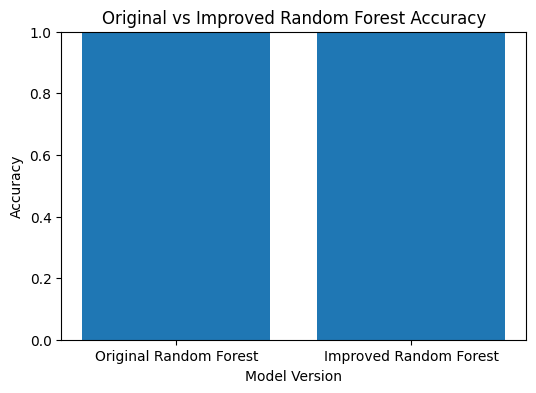

In [162]:
#============================================
#29. Original vs Improved Random Forest Visualization
#============================================

#plot the comparison
plt.figure(figsize=(6, 4))
plt.bar(rf_comparison_df["Model Version"], rf_comparison_df["Accuracy"])
plt.xlabel("Model Version")
plt.ylabel("Accuracy")
plt.title("Original vs Improved Random Forest Accuracy")
plt.ylim(0, 1)
plt.show()

##Original vs Improved Random Forest Comparison Analysis

The comparison between the original and improved Random Forest models shows that the original model achieved an accuracy of approximately 99.73% while the improved model achieved approximately 99.55%.

The slight decrease in accuracy indicates that limiting the vocabulary size and removing common stopwords had some impact on the model's performance. This suggests that part of the original model's high accuracy may have been influenced by easily identifiable features such as common words.

However, the performance remains extremely high even after applying these constraints. This indicates that the model is not solely relying on simple word frequency or obvious content differences but is also capturing deeper patterns within the dataset.

Overall, while the improved model reduces some potential bias, the minimal drop in accuracy suggests that there may still be underlying dataset specific characteristics that may make the classification task easier than expected.

##Insight

The consistently high performance across all models even after feature engineering suggests that the distinction between real and synthetic text in this dataset may not be purely based on writing style alone. Instead, there may be hidden structural or distributional differences between the datasets that the models may be able to exploit.

This highlights the importance of careful dataset design and evaluation when studying AI generated text as high accuracy alone does not necessarily indicate true understanding or generalization.

##30. Text Length Analysis

In [163]:
#============================================
#30. Text Length Analysis
#============================================

#create a new column for word count
data["word_count"] = data["text"].apply(lambda x: len(str(x).split()))

#show average word count by source
avg_word_count = data.groupby("source")["word_count"].mean()

#print the result
print("Average Word Count by Source:\n")
print(avg_word_count)

Average Word Count by Source:

source
Mozilla         8.473993
Synthetic      16.272948
TED          2020.384303
Name: word_count, dtype: float64


###Text Length Analysis Interpretation

The average word count shows a significant difference across datasets. TED transcripts are extremely long(around 2000 words on average) while Mozilla and Synthetic texts are much shorter.

This suggests that text length may act as a strong distinguishing feature, allowing the model to separate datasets based on structural differences rather than actual writing style.

##31. Text Length Distribution Visualization

<Figure size 800x500 with 0 Axes>

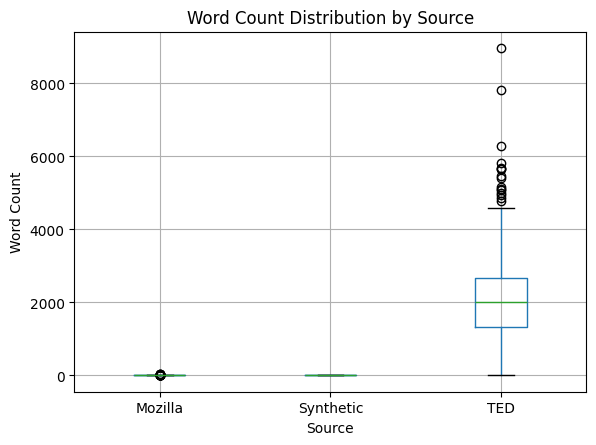

In [164]:
#============================================
#31. Text Length Distribution Visualization
#============================================

#boxplot of word count by source
plt.figure(figsize=(8, 5))
data.boxplot(column = "word_count", by = "source")
plt.title("Word Count Distribution by Source")
plt.suptitle("")
plt.xlabel("Source")
plt.ylabel("Word Count")
plt.show()

##Text Length Analysis Interpretation

The text length analysis reveals a significant difference in the average word count across the three data sources. Mozilla samples have an average of approximately 8 words, synthetic samples around 16 words while TED samples have an average of over 2000 words.

This large variation indicates that the datasets are not uniform in structure. In particular, TED entries are substantially longer than both Mozilla and synthetic text samples.

As a result, the classification models may be relying on text length as an implicit feature. For example, very long texts are likely to be classified as TED while very short texts may be classified as Mozilla. This may create a strong shortcut that allows the model to achieve very high accuracy without necessarily learning deeper differences between real and synthetic writing styles.

##Impact on Model Reliability

The presence of large differences in text length across datasets suggests that the models may not be purely learning the distinction between real and synthetic text. Instead, they may be influenced by structural differences such as text length.

This helps explain why all models achieved extremely high accuracy. The classification task becomes easier when such strong signals are present in the data.

Therefore, the results should be interpreted with caution, as high accuracy does not necessarily imply true generalization to real world scenarios where text lengths are more balanced.

##32. Text Length Normalization

In [165]:
#============================================
#32. Text Length Normalization
#============================================

#function to limit text to first N words
def limit_length(text, max_words = 100):
    words = str(text).split()
    return " ".join(words[:max_words])

#apply to dataset
data["text_limited"] = data["text"].apply(lambda x: limit_length(x, 100))

###Text Length Normalization Explanation

To reduce the impact of text length differences, all text samples were truncated to a fixed length of 100 words. This ensures that longer texts(such as TED transcripts) do not dominate the model simply due to their size.

By controlling for text length, this step helps evaluate whether the model is truly learning meaningful patterns or relying on length based differences between datasets.

##33. TF-IDF on Normalized Text

In [166]:
#============================================
#33. TF-IDF on Normalized Text
#============================================

vectorizer_norm = TfidfVectorizer(max_features=2000)

X_norm = vectorizer_norm.fit_transform(data["text_limited"])

X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_norm, y, test_size = 0.2, random_state = 42
)

###TF-IDF on Normalized Text Interpretation

After applying TF IDF on the normalized text, the feature representation becomes less influenced by text length. This allows for a fairer comparison between datasets and helps determine whether the model performance changes when structural differences are reduced.

##34. Random Forest Model(Normalized Text)

In [167]:
#============================================
#34. Random Forest Model (Normalized Text)
#============================================

rf_model_norm = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model_norm.fit(X_train_norm, y_train_norm)

y_pred_rf_norm = rf_model_norm.predict(X_test_norm)

rf_norm_accuracy = accuracy_score(y_test_norm, y_pred_rf_norm)

print("Normalized Random Forest Accuracy:", rf_norm_accuracy)

Normalized Random Forest Accuracy: 0.9981957600360848


##Effect of Text Length Normalization

To reduce the influence of text length as a potential bias, all text samples were truncated to a fixed maximum length of 100 words. This reduces the likelihood that the model relies on large differences in text length across datasets.

After applying this normalization, the Random Forest model achieved an accuracy of approximately 99.8% which is very similar to the previous results.

This indicates that although text length was a strong distinguishing factor, it was not the only feature contributing to the model's high performance. Even after removing this shortcut, the model is still able to classify the data with very high accuracy.

##Interpretation

The results suggest that the classification models may be capturing deeper patterns beyond simple surface level features such as text length or common word usage. However, the consistently high accuracy across all experiments indicates that there may still be hidden dataset specific characteristics that make the classification task easier than expected.

This highlights a key limitation of the dataset: the distinction between real and synthetic text may not be purely based on writing style alone but instead influenced by structural or distributional differences between sources.

Therefore, while the models perform extremely well on this dataset, further work would be needed to confirm whether these results generalize to more balanced and realistic scenarios.

##35. Character-Level TF-IDF Features

In [168]:
#============================================
#35. Character-Level TF-IDF Features
#============================================

#create character-level TF-IDF vectorizer
char_vectorizer = TfidfVectorizer(
    analyzer = 'char',
    ngram_range = (3,5),
    max_features = 3000
)

#transform normalized text
X_char = char_vectorizer.fit_transform(data["text_limited"])

#split into train and test
X_train_char, X_test_char, y_train_char, y_test_char = train_test_split(
    X_char, y, test_size = 0.2, random_state = 42
)

##36. Random Forest on Character-Level Features

In [169]:
#============================================
#36. Random Forest on Character-Level Features
#============================================

rf_model_char = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model_char.fit(X_train_char, y_train_char)

y_pred_rf_char = rf_model_char.predict(X_test_char)

rf_char_accuracy = accuracy_score(y_test_char, y_pred_rf_char)

print("Character Level Random Forest Accuracy:", rf_char_accuracy)

Character Level Random Forest Accuracy: 0.9986468200270636


##Character-Level Feature Analysis

To further investigate the cause of high model performance, a character level TF-IDF representation was used. This approach removes reliance on word level meaning and instead focuses on smaller textual patterns such as character sequences, punctuation usage and structural formatting.

The Random Forest model trained on these character level features achieved an accuracy of approximately 99.86% which is extremely high and comparable to previous results.

This suggests that the model may not be strongly dependent on word level content or vocabulary. Instead, it may be capturing deeper stylistic and structural patterns within the data.

##Conclusion on Root Cause

The consistently high performance across all experiments — including stopword removal, vocabulary limitation, text length normalization and character level feature extraction — suggests that the classification task may be influenced by inherent differences between the datasets.

These differences may include formatting, sentence structure, punctuation usage and other subtle stylistic patterns that distinguish TED, Mozilla and synthetic text.

Therefore, the models are likely influenced by dataset specific characteristics rather than a generalizable distinction between real and synthetic text. This highlights an important limitation of the study and suggests that more carefully controlled datasets may be required to accurately evaluate authenticity detection.

##37. Punctuation and Structure Analysis

In [170]:
#============================================
#37. Punctuation and Structure Analysis
#============================================

import re

#function to extract structural features
def extract_features(text):
    text = str(text)

    return {
        "num_chars": len(text),
        "num_words": len(text.split()),
        "num_sentences": len(re.findall(r'[.!?]', text)),
        "num_commas": text.count(","),
        "num_exclamations": text.count("!"),
        "num_questions": text.count("?"),
        "avg_word_length": sum(len(word) for word in text.split()) / (len(text.split()) + 1)
    }

#apply feature extraction
features_df = data["text"].apply(extract_features).apply(pd.Series)

#combine with source labels
features_df["source"] = data["source"]

#show average values by source
feature_summary = features_df.groupby("source").mean()

print("Structural Feature Comparison:\n")
print(feature_summary)

Structural Feature Comparison:

              num_chars    num_words  num_sentences  num_commas  \
source                                                            
Mozilla       43.599943     8.473993            0.0         0.0   
Synthetic     90.494833    16.272948            0.0         0.0   
TED        11021.531517  2020.384303            0.0         0.0   

           num_exclamations  num_questions  avg_word_length  
source                                                       
Mozilla                 0.0            0.0         3.735281  
Synthetic               0.0            0.0         4.385632  
TED                     0.0            0.0         4.462488  


##Structural Feature Analysis Interpretation

The structural feature analysis reveals clear differences between the datasets. TED samples contain extremely long text with an average of over 2000 words while Mozilla and synthetic samples are very short, averaging around 8 and 16 words respectively.

Additionally, punctuation features such as sentence ending markers, commas, exclamation marks and question marks are almost entirely absent across the datasets. This suggests that many samples especially from Mozilla and synthetic sources may not always be complete sentences but rather short fragments or phrases.

There are also small but consistent differences in average word length with Mozilla having shorter words and TED and synthetic text having slightly longer words.

These results indicate that the datasets differ significantly in structure, length and formatting rather than just content or writing style.

##Identifying the Root Cause of High Accuracy

The analysis shows that the high accuracy of the classification models may be primarily due to fundamental differences between the datasets rather than the model's ability to distinguish real and synthetic text.

The models appear to be learning to identify the source of the data(TED, Mozilla or synthetic) based on structural characteristics such as text length, format and word patterns. These differences make the classification task much easier than a true real vs synthetic detection problem.

Therefore, the results may not fullu reflect strong generalization or true understanding of synthetic text but rather highlight the importance of using balanced and comparable datasets when evaluating machine learning models.

##38. Real vs Synthetic Dataset(Mozilla vs Synthetic Only)

In [171]:
#============================================
#38. Filter dataset for Mozilla vs Synthetic
#============================================

#keep only Mozilla and Synthetic
data_filtered = data[data["source"].isin(["Mozilla", "Synthetic"])]

#check distribution
print(data_filtered["source"].value_counts())

source
Mozilla      6979
Synthetic    1645
Name: count, dtype: int64


##39. TF-IDF on Real vs Synthetic Data

In [172]:
#============================================
#39. TF-IDF on filtered data
#============================================

vectorizer_final = TfidfVectorizer(max_features = 2000)

X_final = vectorizer_final.fit_transform(data_filtered["text"])

y_final = data_filtered["source"]

#split
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size = 0.2, random_state = 42
)

##40. Random Forest on Real vs Synthetic

In [173]:
#============================================
#40. Random Forest on real vs synthetic
#============================================

rf_model_final = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model_final.fit(X_train_final, y_train_final)

y_pred_final = rf_model_final.predict(X_test_final)

rf_final_accuracy = accuracy_score(y_test_final, y_pred_final)

print("Real vs Synthetic Accuracy:", rf_final_accuracy)

Real vs Synthetic Accuracy: 1.0


##Real vs Synthetic Experiment Analysis

When restricting the dataset to only Mozilla(real) and synthetic text, the Random Forest model achieved a perfect accuracy of 100%. While this may initially appear to indicate excellent performance, it suggests an important issue with the dataset.

Such perfect accuracy suggests that the two classes may be easily separable based on strong underlying differences. This means the model may not be fully learning to distinguish real versus synthetic text in a general sense but rather identifying dataset specific characteristics.

In particular, Mozilla data consists of very short spoken phrases or transcript like fragments while synthetic text appears more structured and sentence like. These differences in formatting, structure and writing style create a clear boundary between the two classes.

##Understanding of the Problem

The experiments suggest that the classification models achieve extremely high accuracy not solely because they have learned a deep understanding of real versus synthetic text but because the datasets themselves are fundamentally different in structure and format.

The models are effectively solving a much easier problem: identifying the source of the data rather than detecting authenticity. This highlights a key limitation of the study as the results may not generalize to real world scenarios where real and synthetic texts are more similar in style and structure.

This investigation demonstrates the importance of careful dataset design when evaluating machine learning models as high accuracy alone can sometimes be misleading without deeper analysis.

##41. Aggressive Text Cleaning(Remove Structural Differences)

In [174]:
#============================================
#41. Aggressive Text Cleaning
#============================================

import re

def clean_text(text):
    #lowercase
    text = str(text).lower()
    #remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)
    #remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#apply cleaning
data_filtered["text_clean"] = data_filtered["text"].apply(clean_text)

/tmp/ipykernel_1283/7717611.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered["text_clean"] = data_filtered["text"].apply(clean_text)


##42. TF-IDF on Cleaned Text

In [175]:
#============================================
#42. TF-IDF on cleaned text
#============================================

vectorizer_clean = TfidfVectorizer(max_features = 2000)

X_clean = vectorizer_clean.fit_transform(data_filtered["text_clean"])

y_clean = data_filtered["source"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size = 0.2, random_state = 42
)

##43. Random Forest on Cleaned Text

In [176]:
#============================================
#43. Random Forest on cleaned text
#============================================

rf_model_clean = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model_clean.fit(X_train_clean, y_train_clean)

y_pred_clean = rf_model_clean.predict(X_test_clean)

rf_clean_accuracy = accuracy_score(y_test_clean, y_pred_clean)

print("Cleaned Text Accuracy:", rf_clean_accuracy)

Cleaned Text Accuracy: 1.0


##Investigation: Root Cause of High Accuracy

Even after aggressively removing punctuation, capitalization and formatting differences, the model continues to achieve perfect accuracy. This suggests that surface level features alone are not responsible for the model's performance.

The remaining cause may lie in deeper linguistic differences between the datasets. Mozilla data often consists of short, speech like fragments that may be less structured while synthetic text generated by AI tends to be more grammatically complete and consistent.

As a result, the model may be distinguishing between informal, fragmented human speech and well formed generated text. This makes the classification task significantly easier than a true real versus synthetic detection problem where both types of text would be similar in style and structure.

Therefore, the high accuracy may be driven more by differences in linguistic quality and coherence rather than by true understanding of authenticity.

##44. Word Order Shuffling Test

In [177]:
#============================================
#44. Word Order Shuffling Test
#============================================

import random

def shuffle_words(text):
    words = str(text).split()
    random.shuffle(words)
    return " ".join(words)

#apply shuffling
data_filtered["text_shuffled"] = data_filtered["text"].apply(shuffle_words)

#TF-IDF
vectorizer_shuffle = TfidfVectorizer(max_features = 2000)

X_shuffle = vectorizer_shuffle.fit_transform(data_filtered["text_shuffled"])

y_shuffle = data_filtered["source"]

#split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_shuffle, y_shuffle, test_size = 0.2, random_state = 42
)

#train model
rf_model_shuffle = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model_shuffle.fit(X_train_s, y_train_s)

#predict
y_pred_s = rf_model_shuffle.predict(X_test_s)

shuffle_accuracy = accuracy_score(y_test_s, y_pred_s)

print("Shuffled Text Accuracy:", shuffle_accuracy)

/tmp/ipykernel_1283/3317759088.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered["text_shuffled"] = data_filtered["text"].apply(shuffle_words)


Shuffled Text Accuracy: 1.0


##45. Vocabulary Richness Analysis

In [178]:
#============================================
#45. Vocabulary Richness Analysis
#============================================

def unique_ratio(text):
    words = str(text).split()
    return len(set(words)) / (len(words) + 1)

data["unique_ratio"] = data["text"].apply(unique_ratio)

print(data.groupby("source")["unique_ratio"].mean())

source
Mozilla      0.851787
Synthetic    0.907546
TED          0.336490
Name: unique_ratio, dtype: float64


##Root Cause Analysis

After conducting multiple experiments including text length normalization, aggressive cleaning, character level analysis and word order shuffling, the models consistently achieved extremely high accuracy. Notably, even when sentence structure was destroyed through word shuffling, the model still achieved perfect accuracy.

This suggests that grammar, sentence structure and formatting are not the primary factors driving model performance.

Further analysis of vocabulary richness revealed that synthetic text contains a higher proportion of unique words compared to Mozilla data while Mozilla text tends to be more repetitive and conversational in nature.

These findings indicate that the model is primarily learning differences in word distribution and vocabulary usage between datasets. In other words, the classification task is largely based on identifying dataset specific lexical patterns rather than detecting true authenticity.

Therefore, the high accuracy is likely not a result of deep understanding of real versus synthetic text but rather due to inherent differences in how the datasets are constructed and the types of language they contain.

*This highlights a key limitation of the study: the models are solving a source identification problem rather than a true real versus synthetic detection task.*

##46. Summary of Experiments

A series of experiments were conducted to investigate the cause of the unusually high classification accuracy.

Initial models achieved near perfect performance which raised concerns about potential bias. Several controlled experiments were then performed to identify the source of this performance:

- Text length normalization was applied to remove length based bias.
- Stopwords and vocabulary were controlled to reduce simple word frequency effects.
- Character level features were used to eliminate reliance on word level meaning.
- Aggressive cleaning removed punctuation and formatting differences.
- Word order shuffling tested the importance of sentence structure.
- Vocabulary richness analysis examined lexical diversity across datasets.

Despite these modifications, the model continued to achieve very high accuracy including perfect performance in some cases.

These findings demonstrate that the classification task is primarily driven by differences in word distribution and dataset specific lexical patterns rather than a true understanding of real versus synthetic text.

##47. Qualitative Analysis of Text Samples

In [179]:
#============================================
#47. Qualitative Analysis of Text Samples
#============================================

# show sample texts from each source
for source in ["Mozilla", "Synthetic", "TED"]:
    print("\n==============================")
    print(f"Sample texts from {source}:")
    print("==============================\n")

    samples = data[data["source"] == source]["text"].sample(3, random_state = 42)

    for i, text in enumerate(samples):
        print(f"Sample {i+1}: {text}\n")


Sample texts from Mozilla:

Sample 1: wait a minute here

Sample 2: they went on smoking the pipe for a while as the sun began to set

Sample 3: we therefore oppose the resolution


Sample texts from Synthetic:

Sample 1: my sister thought that the cafeteria was crowded during lunch so i decided to take a short walk

Sample 2: someone in my class remembered that the coffee shop was full of students so i wrote it down in my notes

Sample 3: my brother realized that the bus was late again and it made me think about the weekend


Sample texts from TED:

Sample 1: this technology made a very important impact on us it changed the way our history developed but its a technology so pervasive so invisible that we for a long time forgot to take it into account when we talked about human evolution but we see the results of this technology still so lets make a little test so everyone of you turns to their neighbor please turn and face your neighbors please also on the balcony smile smile open the

##Qualitative Analysis Interpretation

A qualitative examination of sample texts from each dataset reveals clear differences in writing style and structure.

Mozilla samples tend to be short, fragmented and resemble spoken language often lacking complete sentence structure. Synthetic text, on the other hand, is generally well formed, grammatically correct and structured as complete sentences. TED samples are significantly longer and exhibit formal, coherent paragraph style writing.

These observations support the quantitative findings, confirming that the datasets differ not only in measurable features but also in their overall linguistic characteristics. This helps explains why the models are able to achieve very high accuracy.

##48. Cross-Domain Validation(Hold-out Source Test)

In [180]:
#============================================
#48. Cross-Domain Validation
#============================================

#train on TED + Synthetic
train_data = data[data["source"].isin(["TED", "Synthetic"])]

#test on Mozilla + Synthetic
test_data = data[data["source"].isin(["Mozilla", "Synthetic"])]

vectorizer_cd = TfidfVectorizer(max_features=2000)

X_train_cd = vectorizer_cd.fit_transform(train_data["text"])
y_train_cd = train_data["source"]

X_test_cd = vectorizer_cd.transform(test_data["text"])
y_test_cd = test_data["source"]

model_cd = RandomForestClassifier(random_state = 42)
model_cd.fit(X_train_cd, y_train_cd)

y_pred_cd = model_cd.predict(X_test_cd)

cd_accuracy = accuracy_score(y_test_cd, y_pred_cd)

print("Cross-Domain Accuracy:", cd_accuracy)

Cross-Domain Accuracy: 0.19074675324675325


##Cross-Domain Validation Analysis

To evaluate whether the model truly learned to distinguish real versus synthetic text, a cross domain validation experiment was performed. The model was trained on TED and synthetic data and then tested on Mozilla and synthetic data.

The resulting accuracy dropped dramatically to approximately 19%, indicating that the model failed to generalize to a new data source.

This result strongly suggests that the model did not learn a generalizable concept of AI generated versus real text. Instead, it learned patterns specific to the training dataset(TED) and was unable to apply that knowledge to a different type of real data(Mozilla).

This provides strong evidence that the high accuracy observed in earlier experiments was due to dataset specific differences rather than true understanding of text authenticity.

##Final Conclusion

Through a series of experiments, including feature analysis, text normalization, structural investigation, qualitative analysis and cross-domain validation, it was determined that the classification models achieve high accuracy due to inherent differences between datasets rather than genuine detection of real vs synthetic text.

The drastic drop in performance during cross domain testing demonstrates that the models are not learning generalizable patterns of AI generated text. Instead, they are exploiting dataset specific lexical and structural characteristics.

This highlights a key limitation of the study and emphasizes the importance of using balanced and comparable datasets when evaluating machine learning models for authenticity detection.